[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# Train Soccer Pitch Keypoint Detector

---

[![Download Dataset](https://app.roboflow.com/images/download-dataset-badge.svg)](https://universe.roboflow.com/roboflow-jvuqo/football-field-detection-f07vi)

This notebook is based on the [How to Train a YOLOv8 Keypint Detection Model](https://github.com/roboflow/notebooks/blob/main/notebooks/train-yolov8-keypoint.ipynb) notebook from the [roboflow/notebooks](https://github.com/roboflow/notebooks) repository.

## Configure API keys

- Open your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [3]:
!nvidia-smi

Mon Jul 14 02:04:18 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.94                 Driver Version: 560.94         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080      WDDM  |   00000000:06:00.0  On |                  N/A |
| 34%   39C    P8             27W /  350W |    1711MiB /  12288MiB |      5%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os
HOME = os.getcwd()
print(HOME)

c:\Users\moham\Documents\Github\HGP-GO\sports\examples\soccer\notebooks


## Install dependencies

In [8]:
!pip install -q ultralytics roboflo

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
faiss-cpu 1.11.0 requires numpy<3.0,>=1.25.0, but you have numpy 1.24.4 which is incompatible.
langchain-community 0.3.24 requires numpy>=1.26.2; python_version < "3.13", but you have numpy 1.24.4 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\moham\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Imports

In [9]:
from roboflow import Roboflow
from IPython.display import Image

## Pull dataset

In [11]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

ROBOFLOW_API_KEY = "oetSR0O32rWFikQEeiNw"
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("roboflow-jvuqo").project("football-field-detection-f07vi")
version = project.version(12)
dataset = version.download("yolov8")

La syntaxe de la commande n'est pas correcte.


[WinError 2] Le fichier spécifié est introuvable: 'c:\\Users\\moham\\Documents\\Github\\HGP-GO\\sports\\examples\\soccer\\notebooks/datasets'
c:\Users\moham\Documents\Github\HGP-GO\sports\examples\soccer\notebooks
loading Roboflow workspace...
loading Roboflow project...


**NOTE:** Update `data.yaml` structure to align with the latest requirements of the `ultralytics` package.

In [12]:
!sed -i 's|\(train: \).*|\1../train/images|' {dataset.location}/data.yaml
!sed -i 's|\(val: \).*|\1../valid/images|' {dataset.location}/data.yaml

'sed' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.
'sed' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


## Custom training

In [22]:
!yolo task=pose mode=train model=yolov8x-pose.pt data="C:/Users/moham/Documents/Github/HGP-GO/sports/examples/soccer/notebooks/football-field-detection-12/data.yaml" batch=15 epochs=100 imgsz=640 mosaic=0.0 plots=True  > output.txt 2>&1


In [8]:
!ls "C:/Users/moham/Documents/Github/HGP-GO/sports/examples/soccer/notebooks/runs/pose/train6"


'ls' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


c:\Users\moham\Documents\Github\HGP-GO\sports\examples\soccer\notebooks


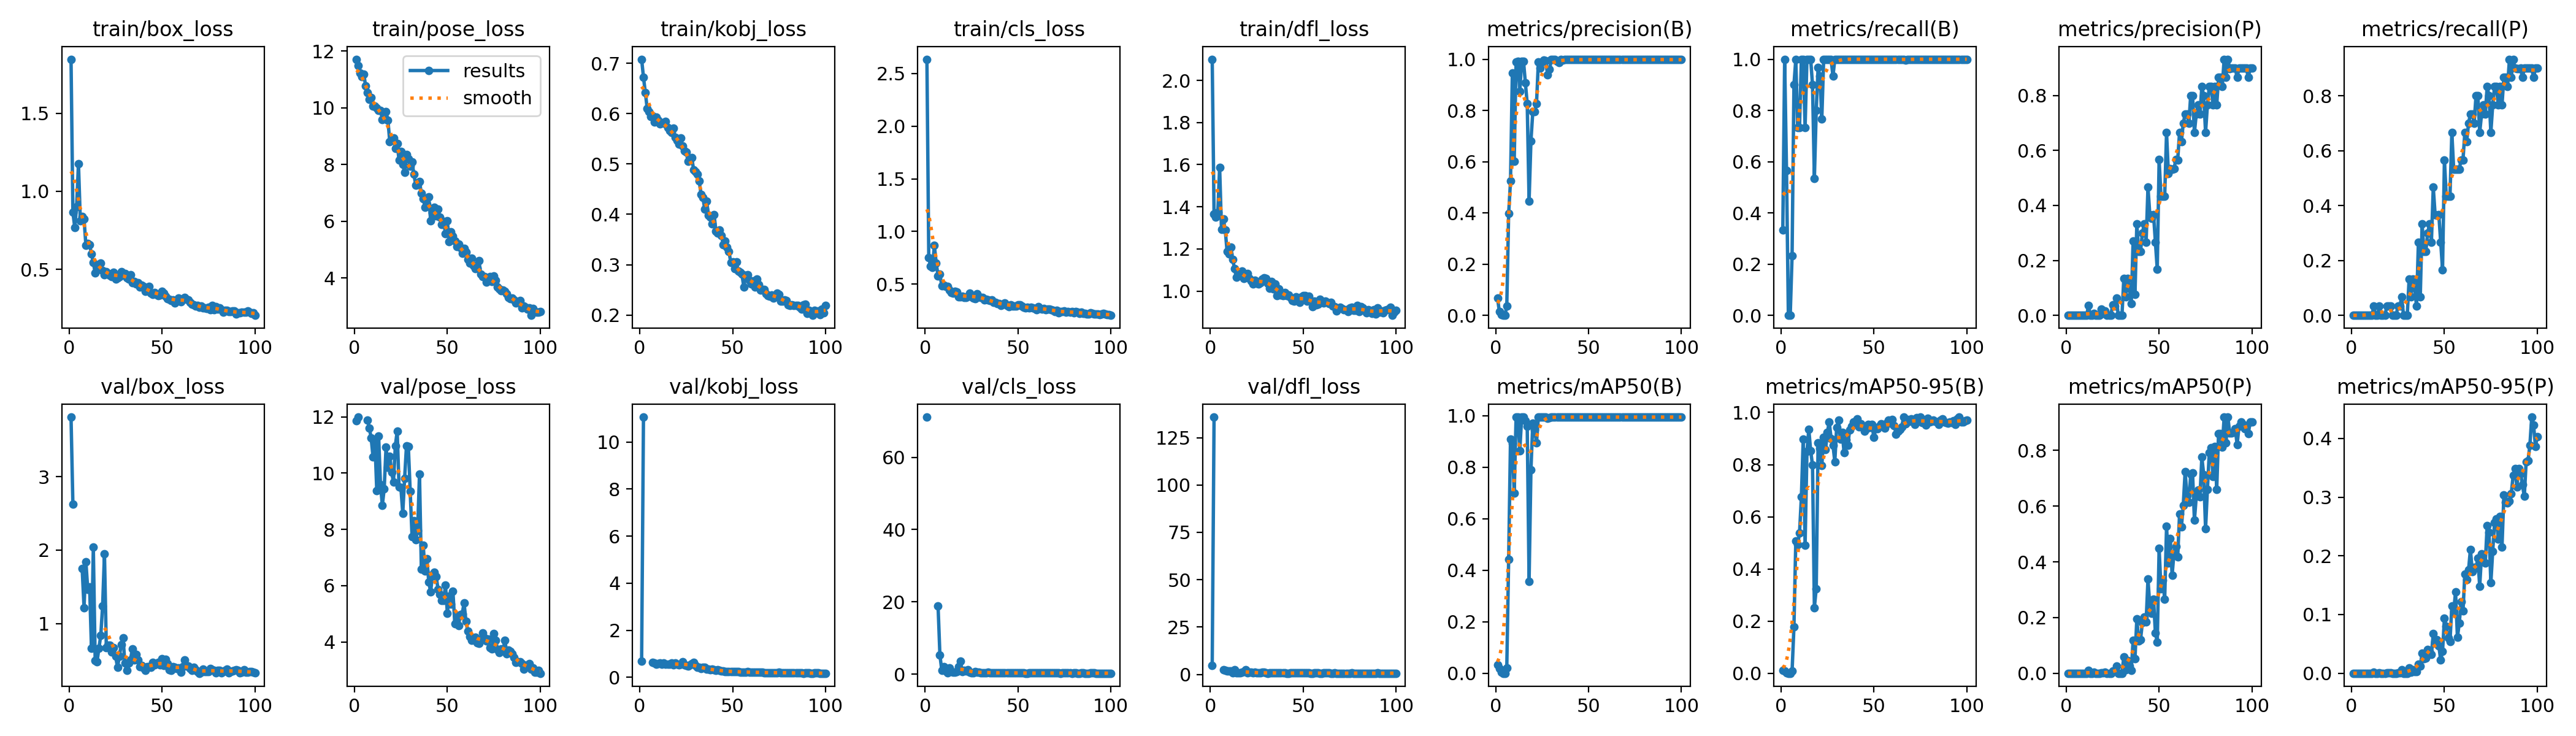

In [14]:
%cd {HOME}
Image(filename="C:/Users/moham/Documents/Github/HGP-GO/sports/examples/soccer/notebooks/runs/pose/train10/results.png", width=600)

c:\Users\moham\Documents\Github\HGP-GO\sports\examples\soccer\notebooks


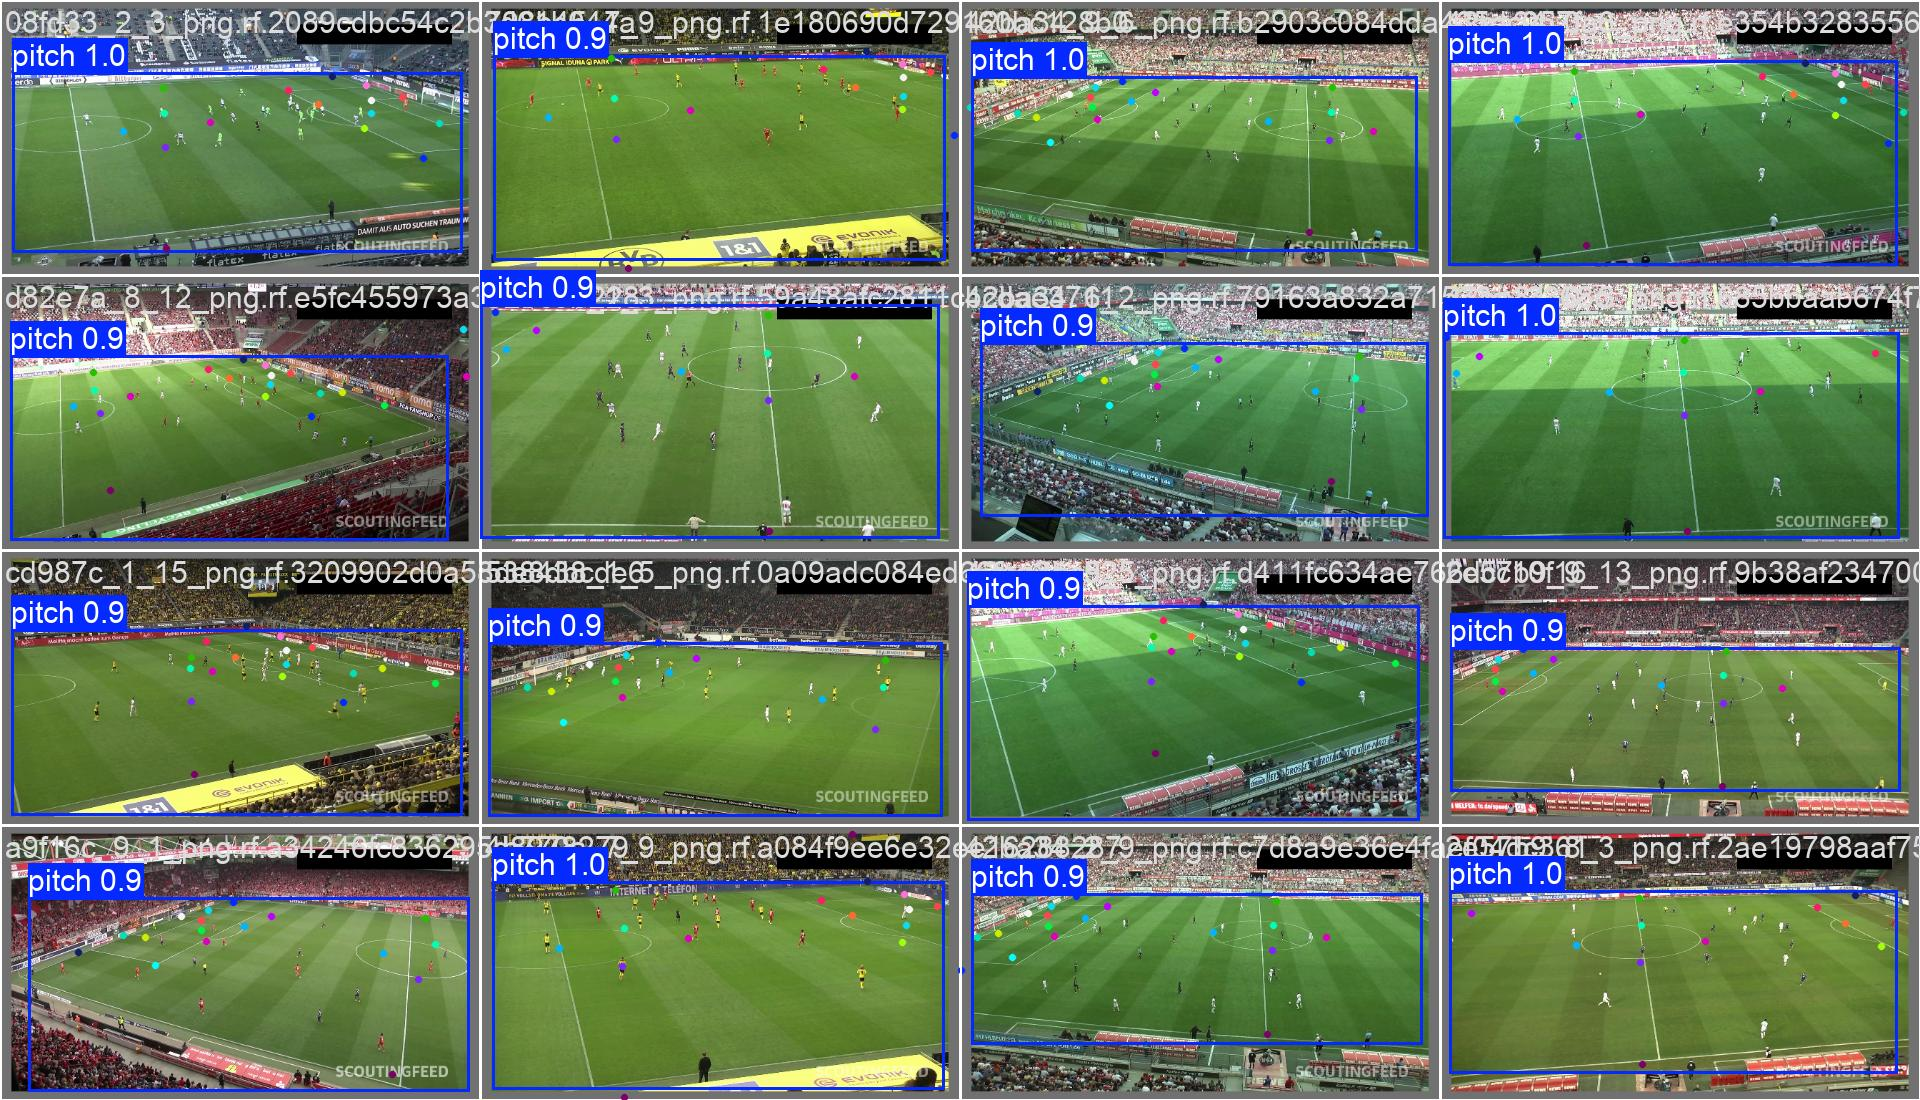

In [17]:
%cd {HOME}
Image(filename="C:/Users/moham/Documents/Github/HGP-GO/sports/examples/soccer/notebooks/runs/pose/train10/val_batch0_pred.jpg", width=600)

## Validate custom model

In [23]:
%cd {HOME}

!yolo task=pose mode=val model="C:/Users/moham/Documents/Github/HGP-GO/sports/examples/soccer/notebooks/runs/pose/train11/weights/best.pt" data="C:/Users/moham/Documents/Github/HGP-GO/sports/examples/soccer/notebooks/football-field-detection-12/data.yaml"

c:\Users\moham\Documents\Github\HGP-GO\sports\examples\soccer\notebooks
Ultralytics 8.3.159  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3080, 12287MiB)
YOLOv8x-pose summary (fused): 121 layers, 69,784,275 parameters, 0 gradients, 264.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1691.8448.4 MB/s, size: 218.1 KB)
                   all         30         30      0.998          1      0.995       0.97      0.932      0.933      0.942      0.414
Speed: 1.6ms preprocess, 16.6ms inference, 0.0ms loss, 5.8ms postprocess per image
Results saved to runs\pose\val3
 Learn more at https://docs.ultralytics.com/modes/val



val: Scanning C:\Users\moham\Documents\Github\HGP-GO\sports\examples\soccer\notebooks\football-field-detection-12\valid\labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100%|██████████| 30/30 [00:00<?, ?it/s]
val: Scanning C:\Users\moham\Documents\Github\HGP-GO\sports\examples\soccer\notebooks\football-field-detection-12\valid\labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100%|██████████| 30/30 [00:00<?, ?it/s]

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95):   0%|          | 0/2 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95):  50%|█████     | 1/2 [00:00<00:00,  1.59it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.91it/s]
                 Class     Images  Insta

## Deploy model on Roboflow

In [ ]:
project.version(dataset.version).deploy(model_type="yolov8-pose", model_path="C:/Users/moham/Documents/Github/HGP-GO/sports/examples/soccer/notebooks/runs/pose/train6/")

Dependency ultralytics==8.0.196 is required but found version=8.2.63, to fix: `pip install ultralytics==8.0.196`
Would you like to continue with the wrong version of ultralytics? y/n: y
View the status of your deployment at: https://app.roboflow.com/roboflow-jvuqo/football-field-detection-f07vi/12
Share your model with the world at: https://universe.roboflow.com/roboflow-jvuqo/football-field-detection-f07vi/model/12


In [25]:
import roboflow

rf = roboflow.Roboflow(api_key="oetSR0O32rWFikQEeiNw")
project = rf.workspace().project("football-field-detection-f07vi-lhm9e")
version = project.version("3")  # Replace x by your dataset version

version.deploy(model_type="yolov8-pose", model_path="C:/Users/moham/Documents/Github/HGP-GO/sports/examples/soccer/notebooks/runs/pose/train11/")


loading Roboflow workspace...
loading Roboflow project...
Dependency ultralytics==8.0.196 is required but found version=8.3.159, to fix: `pip install ultralytics==8.0.196`
View the status of your deployment at: https://app.roboflow.com/football-ajkdi/football-field-detection-f07vi-lhm9e/3
Share your model with the world at: https://universe.roboflow.com/football-ajkdi/football-field-detection-f07vi-lhm9e/model/3
